# Image Segmentation With Keras

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy
import pandas
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tifffile import imread

## Short Version

In the last full run on a Colab T4 GPU, cloning the data (8.5 GB) took 4 minutes and training the first model 25 minutes. The pretrained U-Net then trains for as many epochs. For a live demo, set `SHORT_RUN` to `True` in the next cell:

- a quarter of the training tiles (about 320 instead of 1,296), taken from each of the 16 areas;
- 3 epochs instead of 15 for each of the two models.

It then takes about ten minutes on a T4 (measured: 5 to 6 minutes for both trainings, plus cloning the data), for lower scores, especially that of the first model, trained from scratch.

In [2]:
# Set to True for the short version (see above)
SHORT_RUN = False

# Share of the training tiles used (1.0: all of them)
TRAIN_FRACTION = 0.25 if SHORT_RUN else 1.0
# Number of epochs of each model
EPOCHS = 3 if SHORT_RUN else 15

In [3]:
!nvidia-smi

Wed Oct  7 16:14:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
%%time
!rm -rf sample_data
!git clone https://github.com/mlambda/ign-FNF-2009.git

Cloning into 'ign-FNF-2009'...
remote: Enumerating objects: 4604, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4604 (delta 4), reused 8 (delta 2), pack-reused 4594 (from 1)
Receiving objects: 100% (4604/4604), 3.93 GiB | 5.51 MiB/s, done.
Resolving deltas: 100% (2894/2894), done.
Updating files: 100% (4869/4869), done.
CPU times: user 1.39 s, sys: 345 ms, total: 1.74 s
Wall time: 12min 55s


## Loading the Data

The data are aerial photographs taken by IGN (the French national mapping agency) in 2009 in Lorraine, in north-eastern France: 20 areas of 5 km × 5 km. Each area is cut into 9 × 9 = 81 tiles of 1024 × 1024 pixels (1 pixel = 50 cm on the ground: a tile covers 512 m × 512 m).

- **Input** (`*_irc.tif` files): a *color infrared* (CIR) image. Its three channels are near infrared, red and green, displayed as red, green and blue. Vegetation strongly reflects infrared: it shows up in red.
- **Target** (`*_pfnf_nch.tif` files): the class of each pixel, forest or non-forest, one-hot encoded over two channels. The code keeps its index: 1 for forest, 0 for non-forest. In IGN's sense, a forest isn't just a group of trees: it's an area of more than 5,000 m², at least 20 m wide, where vegetation covers at least 10% of the ground and which isn't used for farming.

2 areas were set aside for validation, and 2 others for testing. All the tiles of an area go to the same set: neighboring tiles look too much alike to measure generalization honestly.

In [5]:
df_train = pandas.read_csv("ign-FNF-2009/train-files.csv")
df_val = pandas.read_csv("ign-FNF-2009/val-files.csv")
df_test = pandas.read_csv("ign-FNF-2009/test-files.csv")

if TRAIN_FRACTION < 1:
  # Short version: part of the tiles of each training area
  df_train = (
    df_train.groupby("coord")
    .sample(frac=TRAIN_FRACTION, random_state=0)
    .reset_index(drop=True)
  )

print("Train coordinates")
print(df_train.coord.unique())

print("Val coordinates")
print(df_val.coord.unique())

print("Test coordinates")
print(df_test.coord.unique())

df_test

Train coordinates
['945_6845' '980_6825' '945_6925' '955_6915' '915_6825' '975_6850'
 '940_6905' '995_6895' '940_6925' '915_6890' '1015_6895' '920_6860'
 '890_6940' '975_6835' '975_6825' '925_6860']
Val coordinates
['970_6845' '910_6935']
Test coordinates
['915_6915' '995_6850']


,Unnamed: 0,Observations,Annotations,latitude,longitude,ligne,colonne,coord
0,0,ign-FNF-2009/test/observations/915_6915_8_2_ob...,ign-FNF-2009/test/annotations/915_6915_8_2_0M5...,915,6915,8,2,915_6915
1,1,ign-FNF-2009/test/observations/995_6850_5_4_ob...,ign-FNF-2009/test/annotations/995_6850_5_4_0M5...,995,6850,5,4,995_6850
2,2,ign-FNF-2009/test/observations/915_6915_4_9_ob...,ign-FNF-2009/test/annotations/915_6915_4_9_0M5...,915,6915,4,9,915_6915
3,3,ign-FNF-2009/test/observations/915_6915_5_4_ob...,ign-FNF-2009/test/annotations/915_6915_5_4_0M5...,915,6915,5,4,915_6915
4,4,ign-FNF-2009/test/observations/995_6850_8_6_ob...,ign-FNF-2009/test/annotations/995_6850_8_6_0M5...,995,6850,8,6,995_6850
...,...,...,...,...,...,...,...,...
155,155,ign-FNF-2009/test/observations/995_6850_9_1_ob...,ign-FNF-2009/test/annotations/995_6850_9_1_0M5...,995,6850,9,1,995_6850
156,156,ign-FNF-2009/test/observations/995_6850_5_8_ob...,ign-FNF-2009/test/annotations/995_6850_5_8_0M5...,995,6850,5,8,995_6850
157,157,ign-FNF-2009/test/observations/995_6850_3_6_ob...,ign-FNF-2009/test/annotations/995_6850_3_6_0M5...,995,6850,3,6,995_6850
158,158,ign-FNF-2009/test/observations/995_6850_4_4_ob...,ign-FNF-2009/test/annotations/995_6850_4_4_0M5...,995,6850,4,4,995_6850


## Studying an Example and Its Annotation

The input is in false colors: vegetation shows up in red. In the target, forest is yellow and the rest purple.

In [6]:
example_input = imread(df_train.Observations[0])
example_annotation = imread(df_train.Annotations[0])

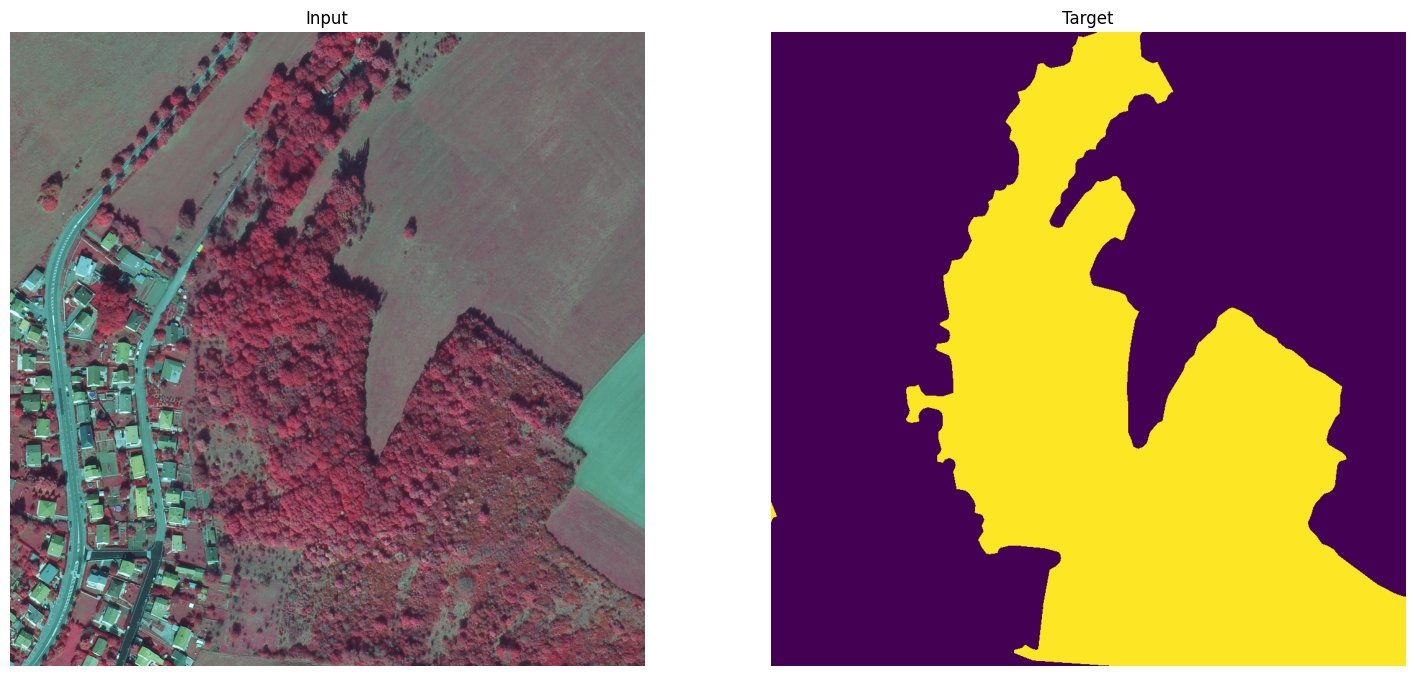

In [7]:
def display_sample(*images: numpy.array) -> None:
  """Show side-by-side an input image, the ground truth and the prediction."""
  figure, axes = plt.subplots(1, len(images), figsize=(18, 18))

  titles = ["Input", "Target", "Prediction"]
  for image, ax, title in zip(images, axes, titles):
    ax.set_title(title)
    if image.ndim == 3 and image.shape[2] == 3:
      # Color infrared image
      ax.imshow(image)
    else:
      if image.ndim == 3:
        # Channel of the forest class (the last one)
        image = image[..., -1]
      # Fixed bounds: forest (1) in yellow, non-forest (0) in purple, even when
      # the whole tile is of a single class
      ax.imshow(image, vmin=0, vmax=1)
    ax.axis("off")
  plt.show()


display_sample(example_input, example_annotation)

## General Options

In [8]:
# Size of the original images
dim_original = 1024

# Size of the network's input images
dim_input = 512

# Number of channels of the input images
num_channel = 3

## Data Augmentation

In image processing, it's extremely important to augment the data through transformations, to make the trained network less sensitive to rotations, crops, etc. The `transform_data` function, if `eval` is `True`, will just center-crop the `X` and `Y` images, and otherwise will apply all the relevant training transformations to these same arrays (random crop, flip, rotation, etc).

It uses the functions of the [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image/) module.

In [9]:
def transform_data(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  eval: bool = False,
  cropped_size: tuple[int, int] = (dim_input, dim_input),
) -> tuple[numpy.ndarray, numpy.ndarray]:
  height, width = X.shape[:2]
  cropped_height, cropped_width = cropped_size
  if eval:
    # Center crop
    crop_params = dict(
      offset_height=(height - cropped_height) // 2,
      offset_width=(width - cropped_width) // 2,
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)
  else:
    # Random rotation
    k = random.choice([None, 1, 3])
    if k is not None:
      X = tf.image.rot90(X, k)
      Y = tf.image.rot90(Y, k)

    # Random crop
    crop_params = dict(
      offset_height=random.randint(0, height - cropped_height),
      offset_width=random.randint(0, width - cropped_width),
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)

    # Horizontal flip
    if random.random() > 0.5:
      X = tf.image.flip_left_right(X)
      Y = tf.image.flip_left_right(Y)

    # Vertical flip
    if random.random() > 0.5:
      X = tf.image.flip_up_down(X)
      Y = tf.image.flip_up_down(Y)
  return X, Y

## Creating a Keras Generator

To define a Keras generator, we'll use the [`keras.utils.Sequence`](https://www.tensorflow.org/api_docs/python/tf/keras/utils/Sequence) class. It mainly needs two methods: `__getitem__`, which is called at each iteration to get the batch to process, and `__len__`, which is called to know the total number of batches the generator will provide. We'll also use `on_epoch_end` to shuffle the dataset before the next iteration.

In [10]:
class DataGenerator(keras.utils.Sequence):
  """Generate data for Keras."""

  def __init__(
    self,
    df: pandas.DataFrame,
    batch_size: int,
    eval: bool,
    cropped_size: tuple[int, int] = (dim_input, dim_input),
  ) -> None:
    """Initialize the generator."""
    self.X_paths = df.Observations
    self.Y_paths = df.Annotations
    assert self.X_paths.shape[0] == self.Y_paths.shape[0]
    self.batch_size = batch_size
    self.eval = eval
    self.cropped_size = cropped_size
    if eval:
      self.indices = numpy.arange(self.X_paths.shape[0])
    else:
      self.indices = numpy.random.permutation(self.X_paths.shape[0])

  def __len__(self):
    """Compute the number of batches per epoch."""
    return int(math.ceil(self.X_paths.shape[0] / self.batch_size))

  def __getitem__(self, index):
    """Generate one batch of data."""
    # Generate indexes of the batch
    start = index * self.batch_size
    Xs = []
    Ys = []
    for i in self.indices[start : start + self.batch_size]:
      X, Y = transform_data(
        imread(self.X_paths[i]),
        imread(self.Y_paths[i]).argmax(axis=-1)[..., numpy.newaxis],
        self.eval,
        self.cropped_size,
      )
      Xs.append(X)
      Ys.append(tf.squeeze(Y))
    return tf.stack(Xs), tf.stack(Ys)

  def on_epoch_end(self):
    """Update indexes after each epoch."""
    if not self.eval:
      self.indices = numpy.random.permutation(self.X_paths.shape[0])


generator = DataGenerator(df_train, 3, True)
X, Y = generator[0]
X.shape, Y.shape

(TensorShape([3, 512, 512, 3]), TensorShape([3, 512, 512]))

## Creating the Model

For the model, we need to go from an image of dimension (batch × height × width × 3) to an output of dimension (batch × height × width).

This first model, taken from a [Keras example](https://keras.io/examples/vision/oxford_pets_image_segmentation/), is an encoder-decoder trained from scratch. The encoder shrinks the image from 512 × 512 to 32 × 32 while extracting features, then the decoder enlarges it back to 512 × 512 to give each pixel a probability of being forest. It has no skip connections between the encoder and the decoder: the decoder must rebuild on its own the fine details lost while shrinking.

In [11]:
# Direct adaptation of the model at
# https://keras.io/examples/vision/oxford_pets_image_segmentation/
# This model lacks the skip connections of a real U-Net
# (https://arxiv.org/abs/1505.04597): the "Pretrained U-Net" section below
# builds one. An overview of segmentation models:
# https://arxiv.org/abs/2001.05566
def get_model(
  input_height: int = dim_input, input_width: int = dim_input
) -> keras.Model:
  inputs = keras.Input(shape=(input_height, input_width, num_channel))

  x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)

  previous_block_activation = x

  for filters in [64, 128, 256]:
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    residual = layers.Conv2D(filters, 1, strides=2, padding="same")(
      previous_block_activation
    )
    x = layers.add([x, residual])
    previous_block_activation = x

  for filters in [256, 128, 64, 32]:
    x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(2)(x)

    residual = layers.UpSampling2D(2)(previous_block_activation)
    residual = layers.Conv2D(filters, 1, padding="same")(residual)
    x = layers.add([x, residual])
    previous_block_activation = x

  x = layers.Conv2D(32, 1, activation="relu")(x)
  x = layers.Dropout(0.9)(x)
  outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

  model = keras.Model(inputs, outputs)
  return model

## Training

We can now use our data generation class to train our model.

On top of accuracy, the share of correctly classified pixels, we track the IoU (intersection over union) of the forest class: the area where the prediction and the target both say "forest", divided by the area where at least one of them does. It's 1 for a perfect mask, and 0 for a model that never predicts forest, whatever its accuracy.

In [12]:
# Build the model
model = get_model()
model.summary()
model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=[
    "accuracy",
    keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
  ],
)

batch_size = 4

# Create the generators
train_generator = DataGenerator(df_train, batch_size, eval=False)
val_generator = DataGenerator(df_val, batch_size, eval=True)

# Train the model, evaluating on the validation generator at the end
# of each epoch
model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=EPOCHS,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_model.weights.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ activation[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │      2,400 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ activation_3[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 2,059,201 (7.86 MB)

 Trainable params: 2,055,425 (7.84 MB)

 Non-trainable params: 3,776 (14.75 KB)

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 174s 361ms/step - accuracy: 0.7404 - iou: 0.5633 - loss: 0.5257 - val_accuracy: 0.6067 - val_iou: 0.0000e+00 - val_loss: 3.7740
Epoch 2/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 95s 294ms/step - accuracy: 0.7895 - iou: 0.6806 - loss: 0.3887 - val_accuracy: 0.9170 - val_iou: 0.7952 - val_loss: 0.3148
Epoch 3/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 101s 310ms/step - accuracy: 0.8135 - iou: 0.7082 - loss: 0.3479 - val_accuracy: 0.9453 - val_iou: 0.8668 - val_loss: 0.1927
Epoch 4/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 132s 280ms/step - accuracy: 0.8335 - iou: 0.7309 - loss: 0.3203 - val_accuracy: 0.9401 - val_iou: 0.8553 - val_loss: 0.2625
Epoch 5/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 96s 297ms/step - accuracy: 0.8420 - iou: 0.7434 - loss: 0.2903 - val_accuracy: 0.9248 - val_iou: 0.8294 - val_loss: 0.2381
Epoch 6/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 101s 311ms/step - accuracy: 0.8421 - iou: 0.7422 - loss: 0.2859 - val_accuracy: 0.9456 - val_iou: 0.8696 - val_loss: 0.1886
Epoch 7/15
324

## Applying the Model to the Test Data

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 234ms/step - accuracy: 0.9782 - iou: 0.9653 - loss: 0.0844
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
(8, 512, 512, 3) (8, 512, 512) (8, 512, 512)


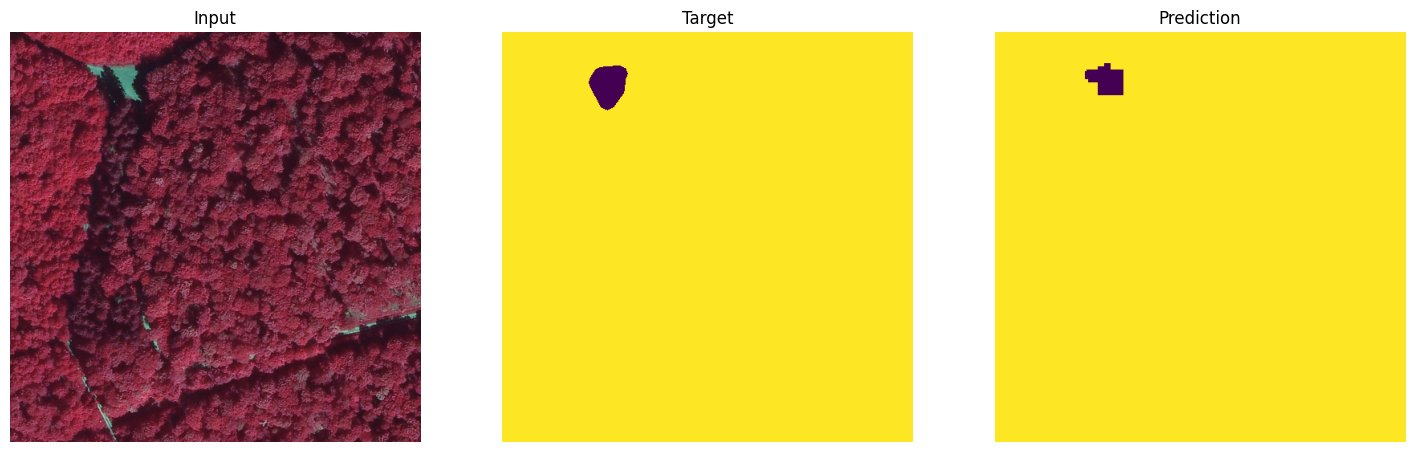

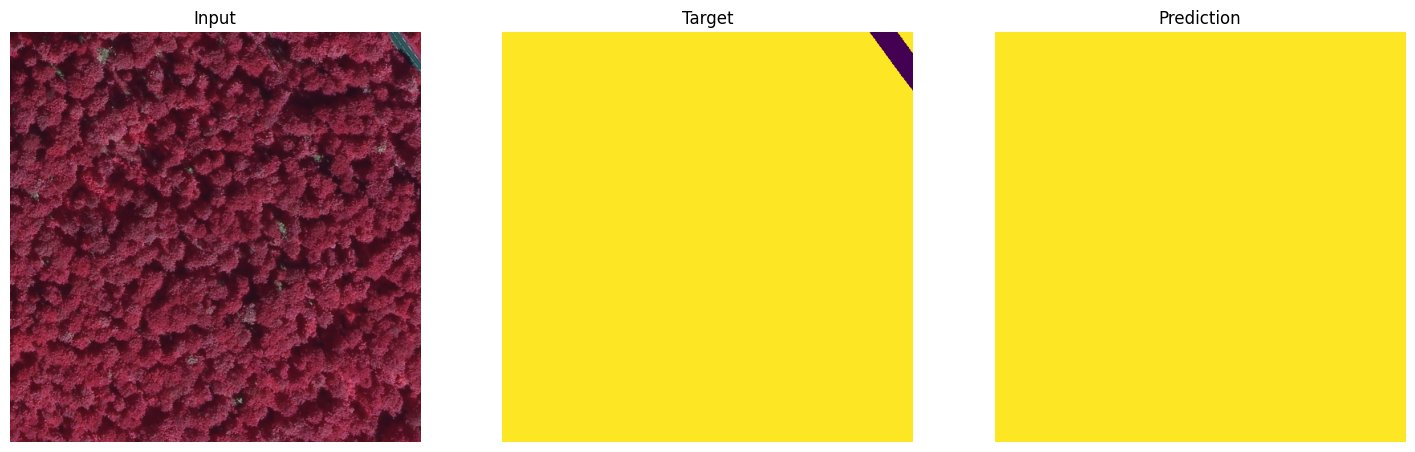

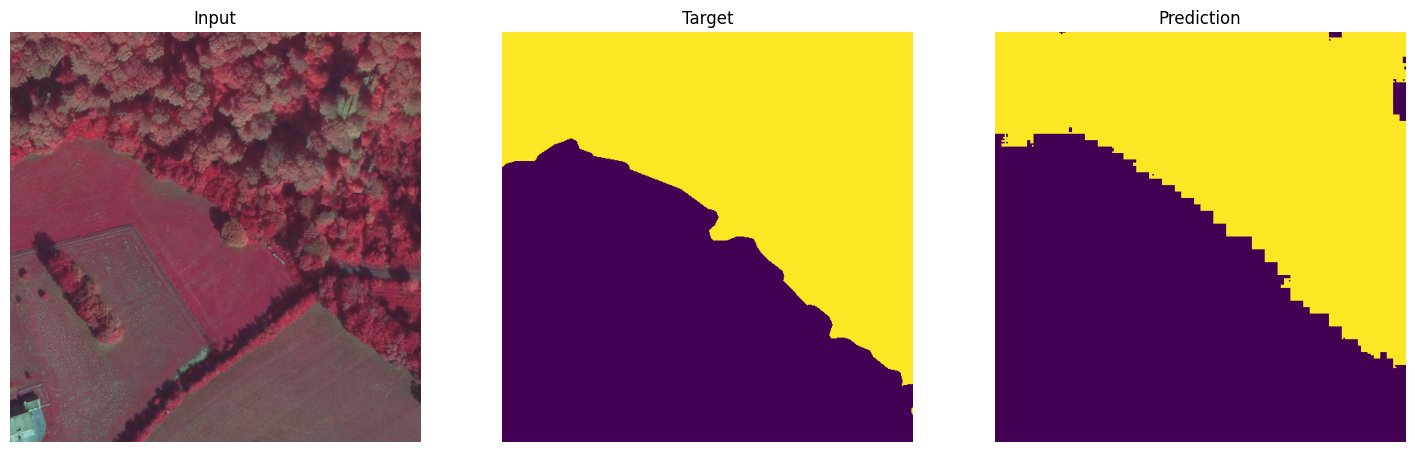

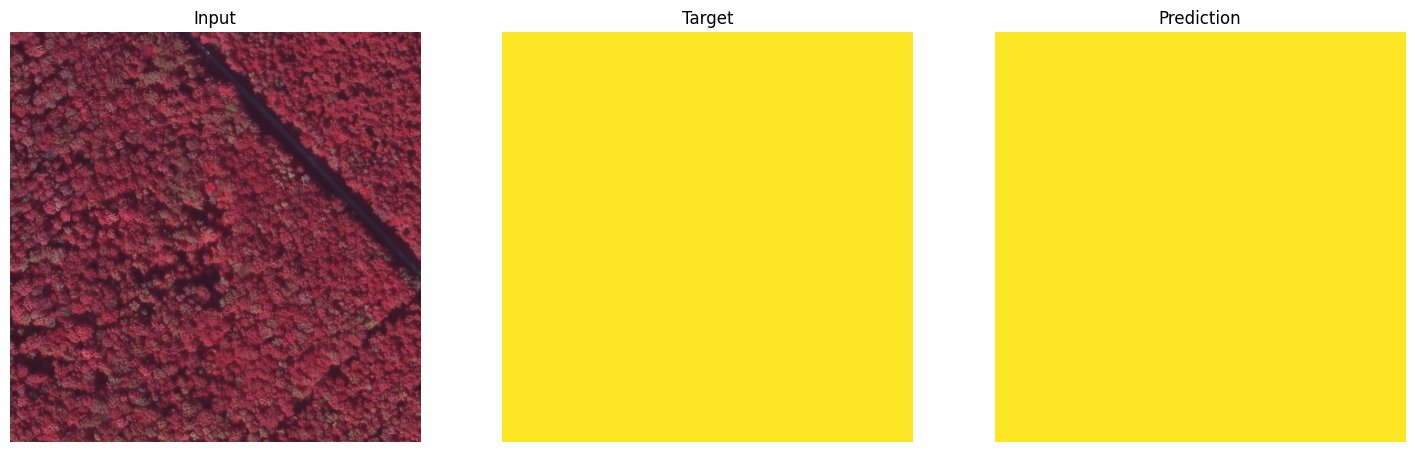

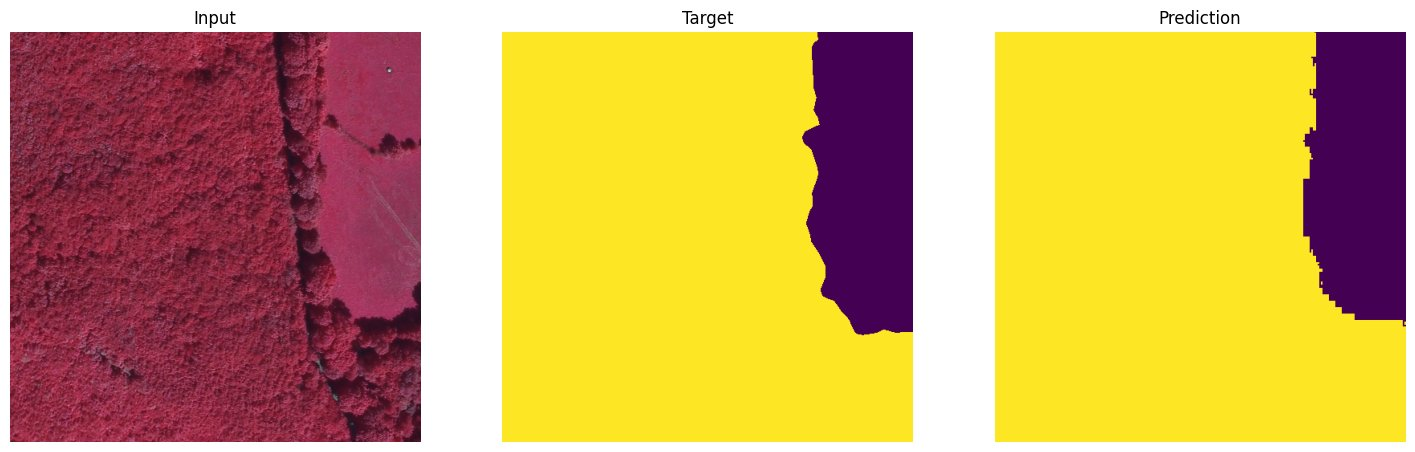

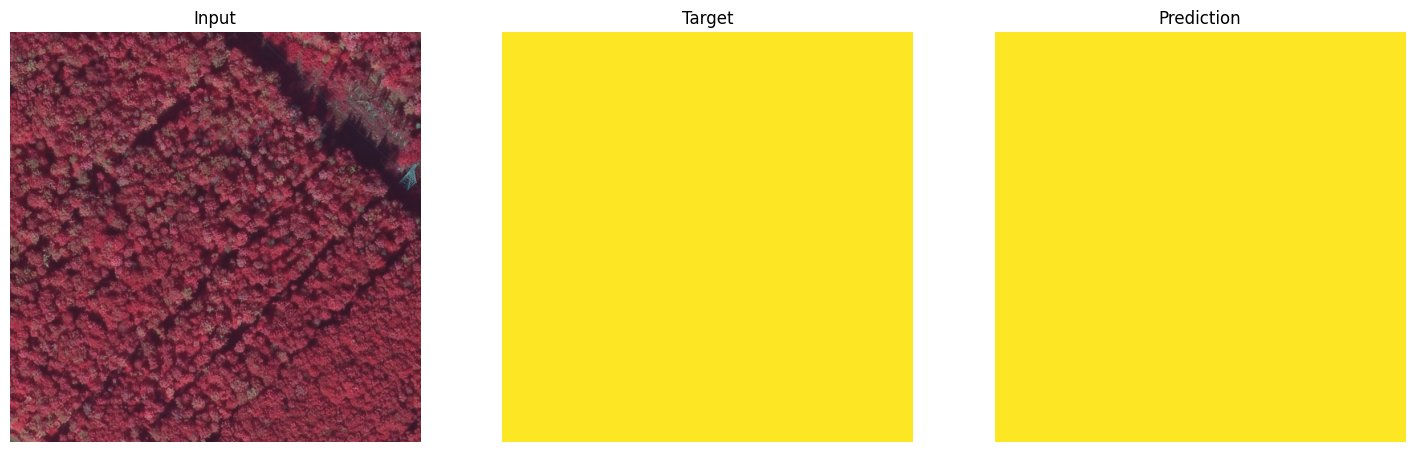

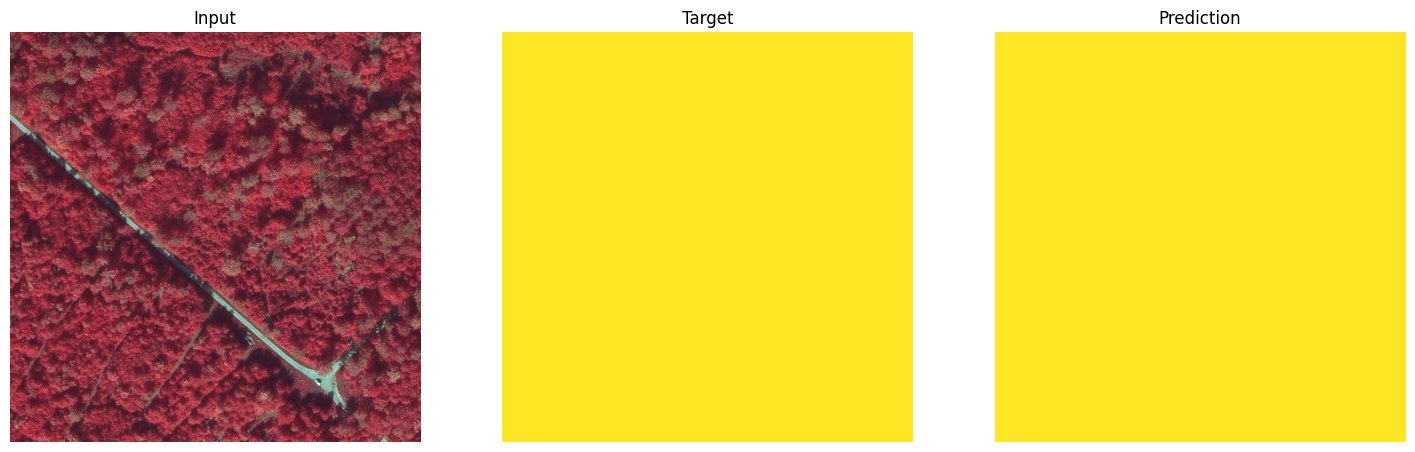

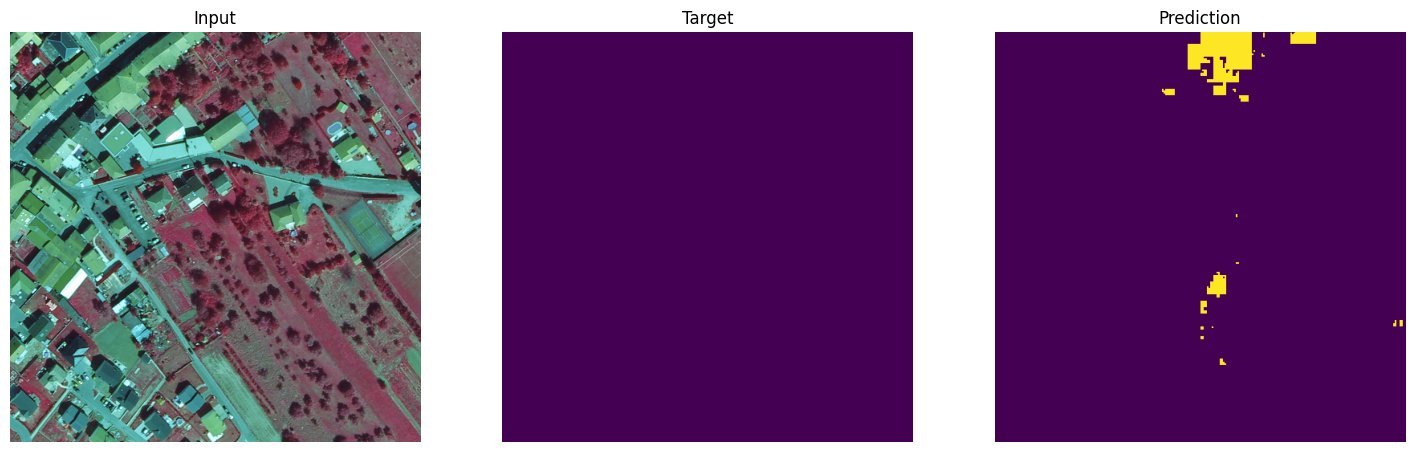

In [13]:
# Load the best model
model.load_weights("best_model.weights.h5")

# Scores of each model on the test tiles
test_generator = DataGenerator(df_test, 8, eval=True)
results = {
  "Encoder-decoder trained from scratch": model.evaluate(
    test_generator, return_dict=True
  )
}

# Predictions on 8 test tiles: forest if its probability exceeds the threshold
threshold = 0.5
X, Y = test_generator[6]
preds = (model.predict(X)[..., 0] > threshold).astype("uint8")

print(X.shape, Y.shape, preds.shape)

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

## Pretrained U-Net

The previous model starts from scratch, and its decoder must rebuild the fine contours from an image shrunk to 32 × 32. A [U-Net](https://arxiv.org/abs/1505.04597) addresses both points:

- **a pretrained encoder**: [MobileNetV2](https://arxiv.org/abs/1801.04381), trained to classify ImageNet photos, already knows how to extract edges, textures and shapes. We freeze it (`trainable = False`): only the decoder learns. ImageNet has no infrared images, but these visual features remain useful;
- **skip connections**: at each resolution (256, 128, 64 then 32 pixels wide), the decoder receives, on top of its own enlarged output, the features the encoder computed at that same resolution. It thus recovers the details lost while shrinking.

The data, the augmentations and the number of epochs stay the same as for the first model.

In [14]:
def get_pretrained_unet(
  input_height: int = dim_input, input_width: int = dim_input
) -> keras.Model:
  # Encoder: MobileNetV2 pretrained on ImageNet, without its classification
  # head. Keras warns that it loads the weights meant for 224 × 224 images: its
  # convolutions apply to any image size.
  mobilenet = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(input_height, input_width, num_channel),
  )
  # Encoder outputs reused by the decoder, from the finest (256 × 256) to the
  # coarsest (32 × 32), then the bottom of the "U" (16 × 16)
  layer_names = [
    "block_1_expand_relu",
    "block_3_expand_relu",
    "block_6_expand_relu",
    "block_13_expand_relu",
    "block_16_project",
  ]
  encoder = keras.Model(
    mobilenet.input,
    [mobilenet.get_layer(name).output for name in layer_names],
    name="encoder",
  )
  encoder.trainable = False

  inputs = keras.Input(shape=(input_height, input_width, num_channel))
  # MobileNetV2 expects pixels between -1 and 1
  x = layers.Rescaling(1 / 127.5, offset=-1)(inputs)
  *skips, x = encoder(x)

  # Decoder: at each step, double the resolution and concatenate the encoder's
  # output of the same resolution (skip connection)
  for filters, skip in zip([256, 128, 64, 32], reversed(skips)):
    x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

  # Last doubling, up to the input image's resolution
  x = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(x)
  outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)
  return keras.Model(inputs, outputs, name="unet")

In [15]:
unet = get_pretrained_unet()
unet.summary()
unet.compile(
  # Only the decoder, which starts from scratch, learns: a larger learning rate
  # than for the first model suits it
  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
  loss="binary_crossentropy",
  metrics=[
    "accuracy",
    keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
  ],
)

unet.fit(
  train_generator,
  validation_data=val_generator,
  epochs=EPOCHS,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_unet.weights.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

/tmp/ipykernel_15608/4088002571.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = keras.applications.MobileNetV2(


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 512, 512,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 256, 256, │  1,841,984 │ rescaling[0][0]   │
│ (Functional)        │ 96), (None, 128,  │            │                   │
│                     │ 128, 144), (None, │            │                   │
│                     │ 64, 64, 192),     │            │                   │
│                     │ (None, 32, 32,    │            │                   │
│                     │ 576), (None, 16,  │            │                   │
│                     │ 16, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 32, 32,    │    737,536 │ encoder[0][4]     │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 832)              │            │ encoder[0][3]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │  1,917,184 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 64, 64,    │    295,040 │ activation_15[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 320)              │            │ encoder[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 64,    │    368,768 │ concatenate_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 128, 128,  │     73,792 │ activation_16[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 208)              │            │ encoder[0][1]   

 Total params: 5,416,097 (20.66 MB)

 Trainable params: 3,573,153 (13.63 MB)

 Non-trainable params: 1,842,944 (7.03 MB)

Epoch 1/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 152s 335ms/step - accuracy: 0.9103 - iou: 0.8279 - loss: 0.2704 - val_accuracy: 0.9512 - val_iou: 0.8850 - val_loss: 0.1683
Epoch 2/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 70s 217ms/step - accuracy: 0.9435 - iou: 0.8874 - loss: 0.1933 - val_accuracy: 0.9204 - val_iou: 0.7985 - val_loss: 0.2598
Epoch 3/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 72s 222ms/step - accuracy: 0.9565 - iou: 0.9113 - loss: 0.1395 - val_accuracy: 0.9319 - val_iou: 0.8289 - val_loss: 0.2281
Epoch 4/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 70s 217ms/step - accuracy: 0.9571 - iou: 0.9115 - loss: 0.1401 - val_accuracy: 0.9556 - val_iou: 0.8915 - val_loss: 0.1218
Epoch 5/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 71s 219ms/step - accuracy: 0.9583 - iou: 0.9140 - loss: 0.1347 - val_accuracy: 0.9454 - val_iou: 0.8630 - val_loss: 0.1510
Epoch 6/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 69s 214ms/step - accuracy: 0.9623 - iou: 0.9227 - loss: 0.1197 - val_accuracy: 0.9425 - val_iou: 0.8551 - val_loss: 0.1555
Epoch 7/15
324/324 ━━

### Applying the Model to the Test Data

20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 231ms/step - accuracy: 0.9786 - iou: 0.9659 - loss: 0.0645
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


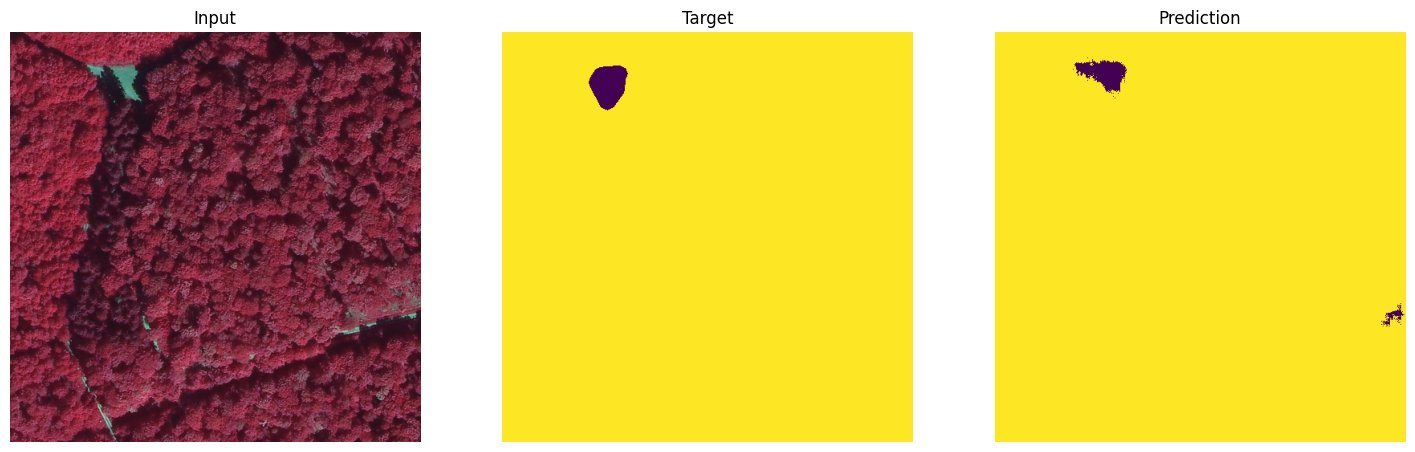

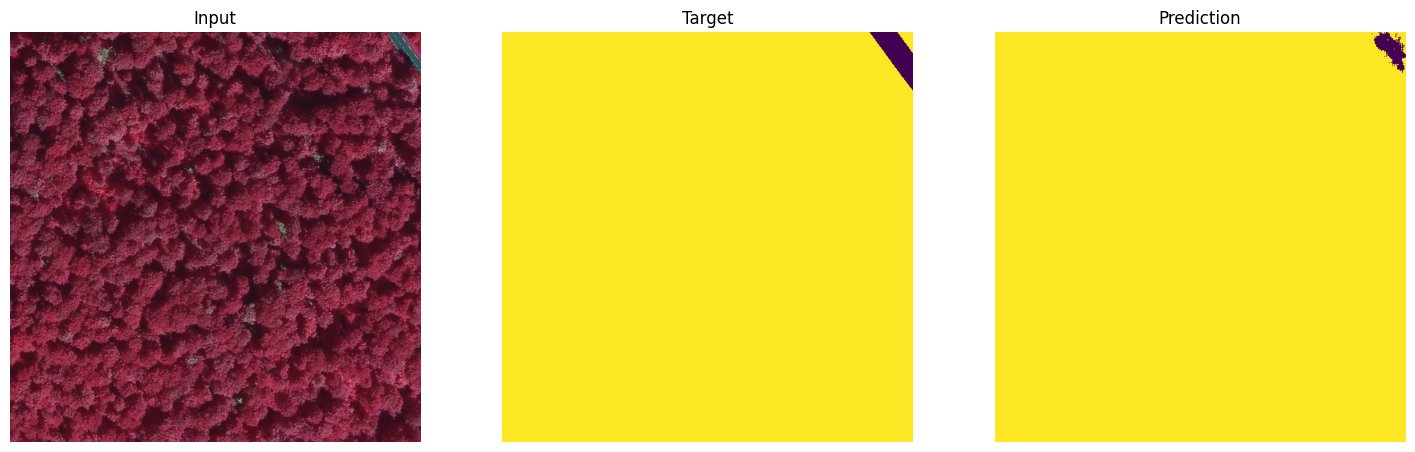

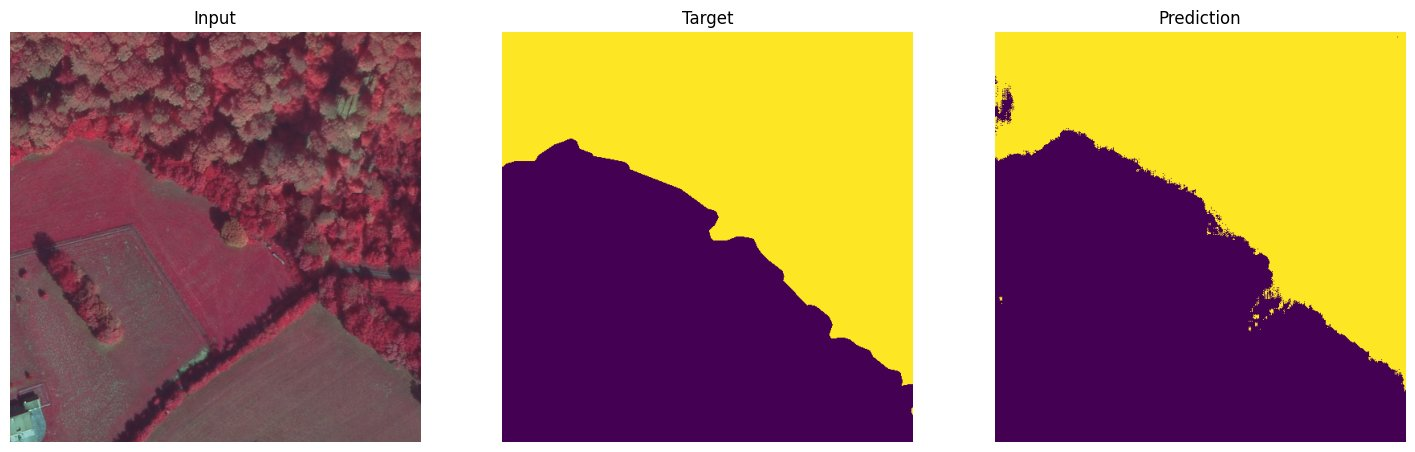

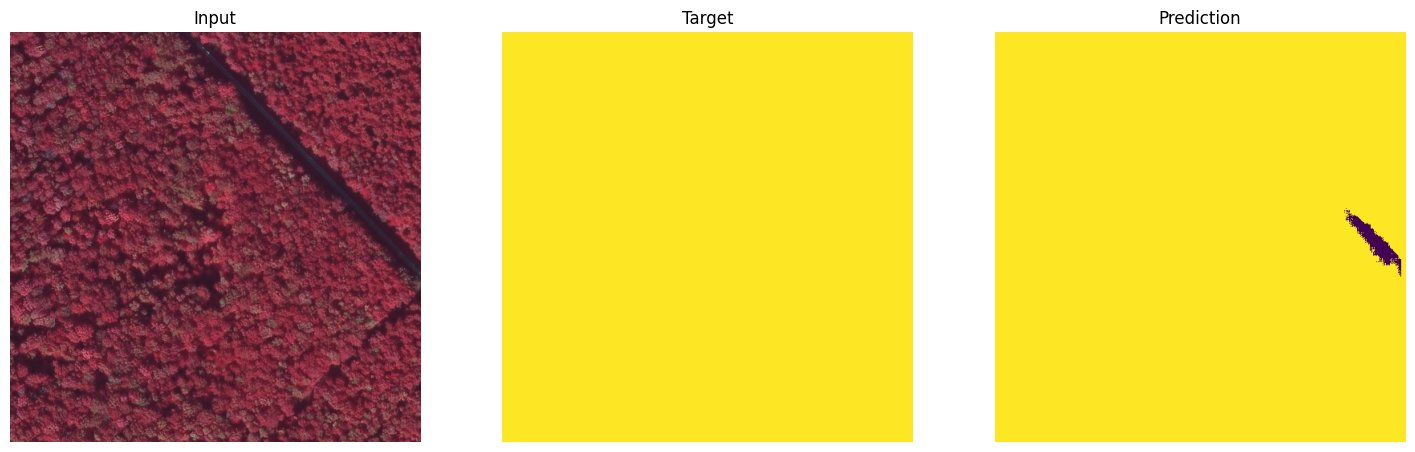

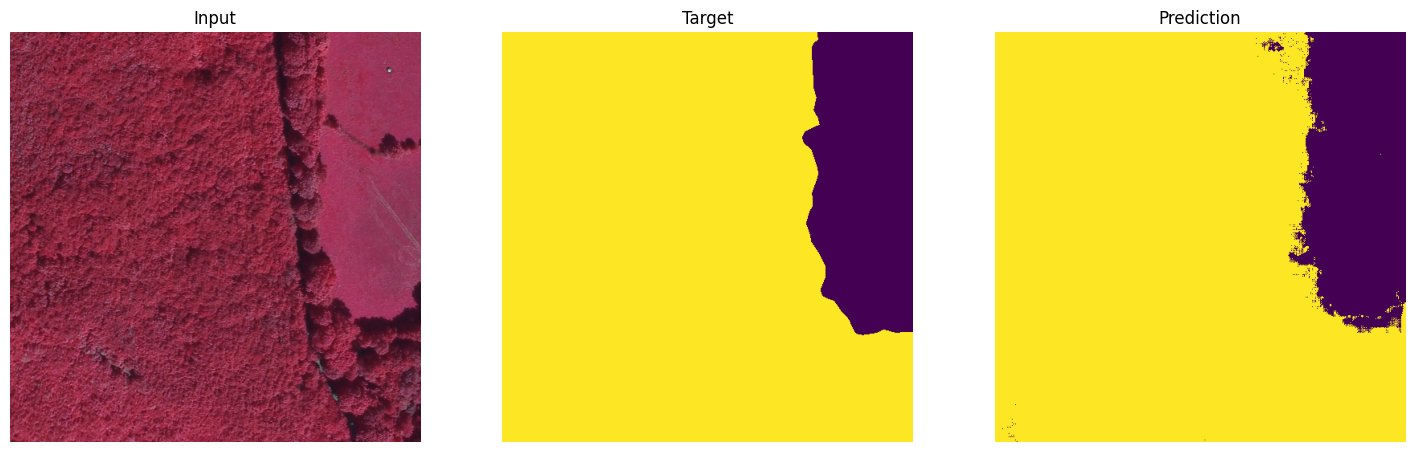

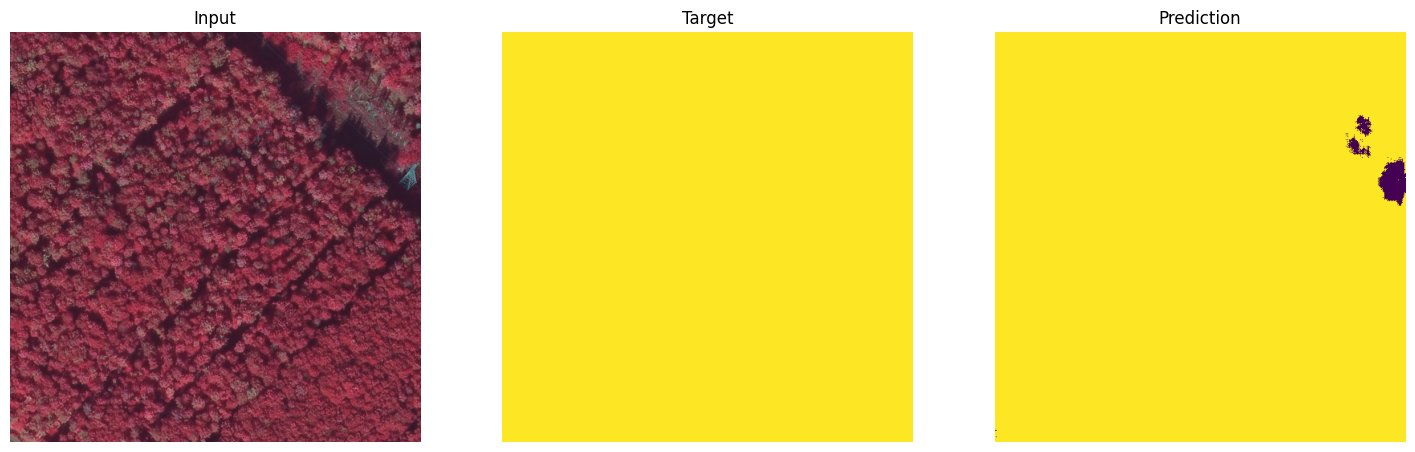

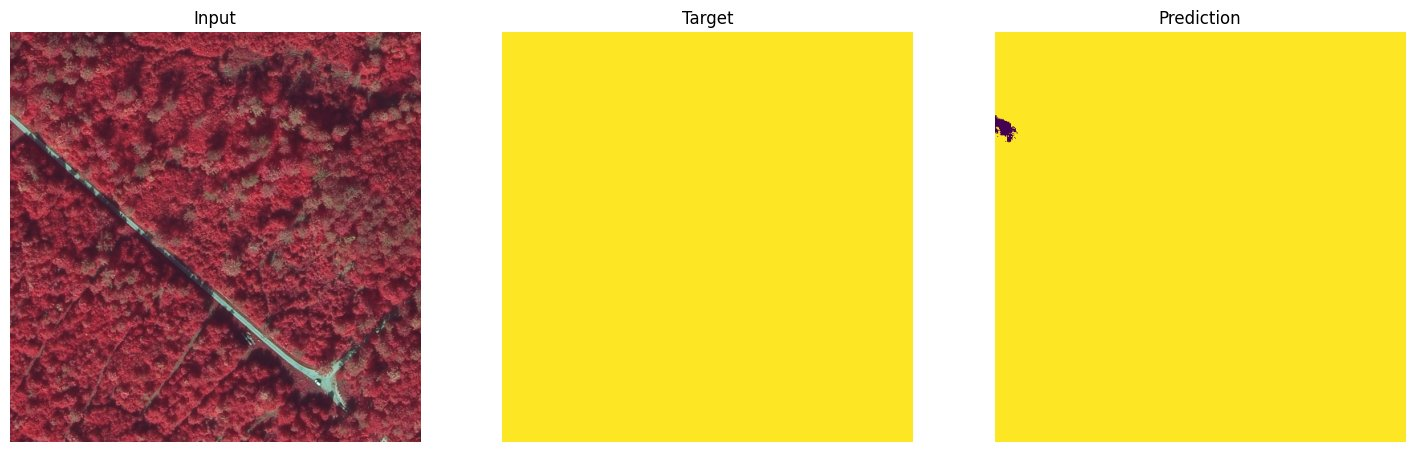

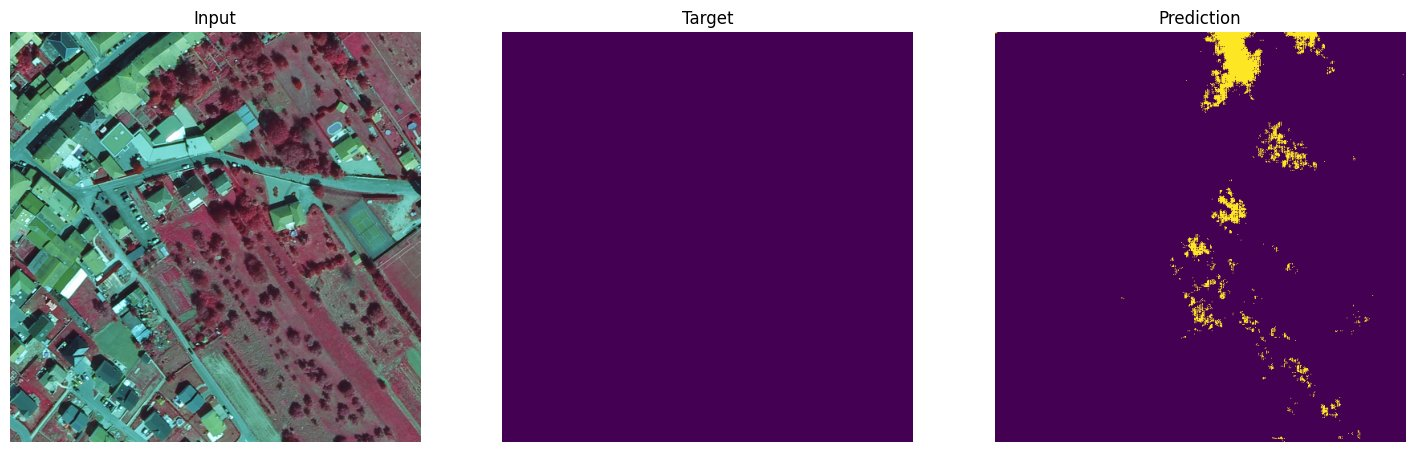

In [16]:
# Load the best model
unet.load_weights("best_unet.weights.h5")

results["Pretrained U-Net (MobileNetV2)"] = unet.evaluate(
  test_generator, return_dict=True
)

# The same 8 test tiles as for the first model
preds = (unet.predict(X)[..., 0] > threshold).astype("uint8")

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

## Comparison

The scores of both models on the test tiles. To read accuracy, compare it with the share of the most frequent class: a model that always answered that class would already get that accuracy, with a zero or poor forest IoU.

With the full version, both models end up close. The short version shows what pretraining brings: after 3 epochs, in our run, the first model still predicted no forest pixel at all (IoU 0), while the pretrained U-Net already reached 0.97.

In [17]:
# Share of forest pixels in the (cropped) test tiles
forest_pixels = sum(
  float(tf.reduce_sum(test_generator[i][1])) for i in range(len(test_generator))
)
forest_share = forest_pixels / (len(df_test) * dim_input * dim_input)
print(f"Forest share: {forest_share:.1%}")
print(
  "Accuracy when always answering the most frequent class:",
  f"{max(forest_share, 1 - forest_share):.1%}",
)

pandas.DataFrame(results).T[["accuracy", "iou"]].round(3)

Forest share: 61.5%
Accuracy when always answering the most frequent class: 61.5%


,accuracy,iou
Encoder-decoder trained from scratch,0.978,0.965
Pretrained U-Net (MobileNetV2),0.979,0.966


## Key Takeaways

- Semantic segmentation classifies each pixel: here, forest or non-forest, on color infrared aerial photos.
- Accuracy mostly counts the easy pixels, far from forest edges. The forest class's IoU judges the shape of the predicted areas: that's the one to compare.
- The U-Net's skip connections give back to the decoder the details the encoder lost while shrinking the image.
- An encoder pretrained on ImageNet brings visual features it has already learned, even for infrared images it has never seen: that's transfer learning. Only the decoder is left to train: a few epochs are enough, where the model trained from scratch needs many more to catch up.
- All the tiles of an area stay in the same set (training, validation or test): otherwise, nearly identical neighboring tiles would inflate the scores.